In [4]:
import numpy as np
import matplotlib.pyplot as plt 

## Desiderata 

Make a dataset of ring images with different radii and decay for the ring. We can keep the resolution low to keep resources low for the training of our compressor/encoder/embedding function. 

I propose to have a resolution around $64 \times 64$ pixels. 
1) The radius can be uniformly sampled as $$r\sim \mathcal{U}(10, 30)$$ (here the units of $r$ is in number of pixels)
2) The decay can be sampled uniformly as well. 

The equation of the ring to implement depends on two independent parameters/causes: 
$$
I(x, y) = \exp\left(-\frac{(\sqrt{x^2 + y^2} - R)^2}{\lambda}\right)
$$

$\lambda$ controls the thickness of the ring here.  

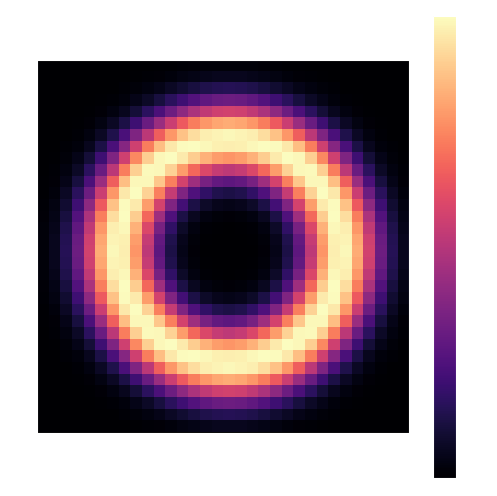

In [5]:
from functools import partial

def make_rings(x, y, radius = 10, sigma = 3, center = 32//2): 
    """
    x and y are arrays created from a np.meshgrid. 
    """
    r =  np.sqrt((x-center) ** 2 + (y - center) ** 2)
    return np.exp( - (r - radius) ** 2 / sigma)

x = np.arange(0, 32) / 32
y = np.arange(0, 32) / 32
X, Y = np.meshgrid(x,y)

ring = make_rings(X, Y, sigma = 1e-2, radius = 0.3, center = 0.5)

fig, axs = plt.subplots(1, 1, figsize = (6, 6))

im = axs.imshow(ring, cmap = "magma", vmin = 0, vmax = 1)
plt.colorbar(im)

Now, sample the ring parameters from uniform prior distributions

In [6]:
from tqdm import tqdm 
prior_params_config = {
    "radius": {"low": 0.1, "high": 0.3}, 
    "sigma": {"low": 1e-4, "high": 1e-2}
}

radius_prior = prior_params_config["radius"]
sigma_prior = prior_params_config["sigma"]
prior_sampler_radius = lambda size: np.random.uniform(radius_prior["low"], radius_prior["high"], size = size)
prior_sampler_sigma = lambda size: np.random.uniform(sigma_prior["low"], sigma_prior["high"], size = size)

dataset_size = 10_000

# Creating latent factors
radius = prior_sampler_radius(size = dataset_size)
sigma = prior_sampler_sigma(size = dataset_size)
radius = (radius - radius_prior["low"]) / (radius_prior["high"] - radius_prior["low"]) # [a, b] -> [0, 1]
sigma = (sigma - sigma_prior["low"]) / (sigma_prior["high"] - sigma_prior["low"]) # [a, b] -> [0, 1]

theta = np.stack([radius, sigma]).T
theta_normalized =   # [a, b] -> [0, 1]

# Creating simulations from it 
images = []
for params in tqdm(theta): 
    image = make_rings(X, Y, radius = params[0], sigma = params[1], center = 0.5)
    images.append(image) 

images = np.array(images)

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:00<00:00, 54999.33it/s]


### Saving the dataset. 

In [7]:
from datasets import Dataset
dset = Dataset.from_dict({
            "theta": theta,
            "image": images 
        })
dset.save_to_disk("/home/noedia/links/scratch/crl/experiments/rings/data")

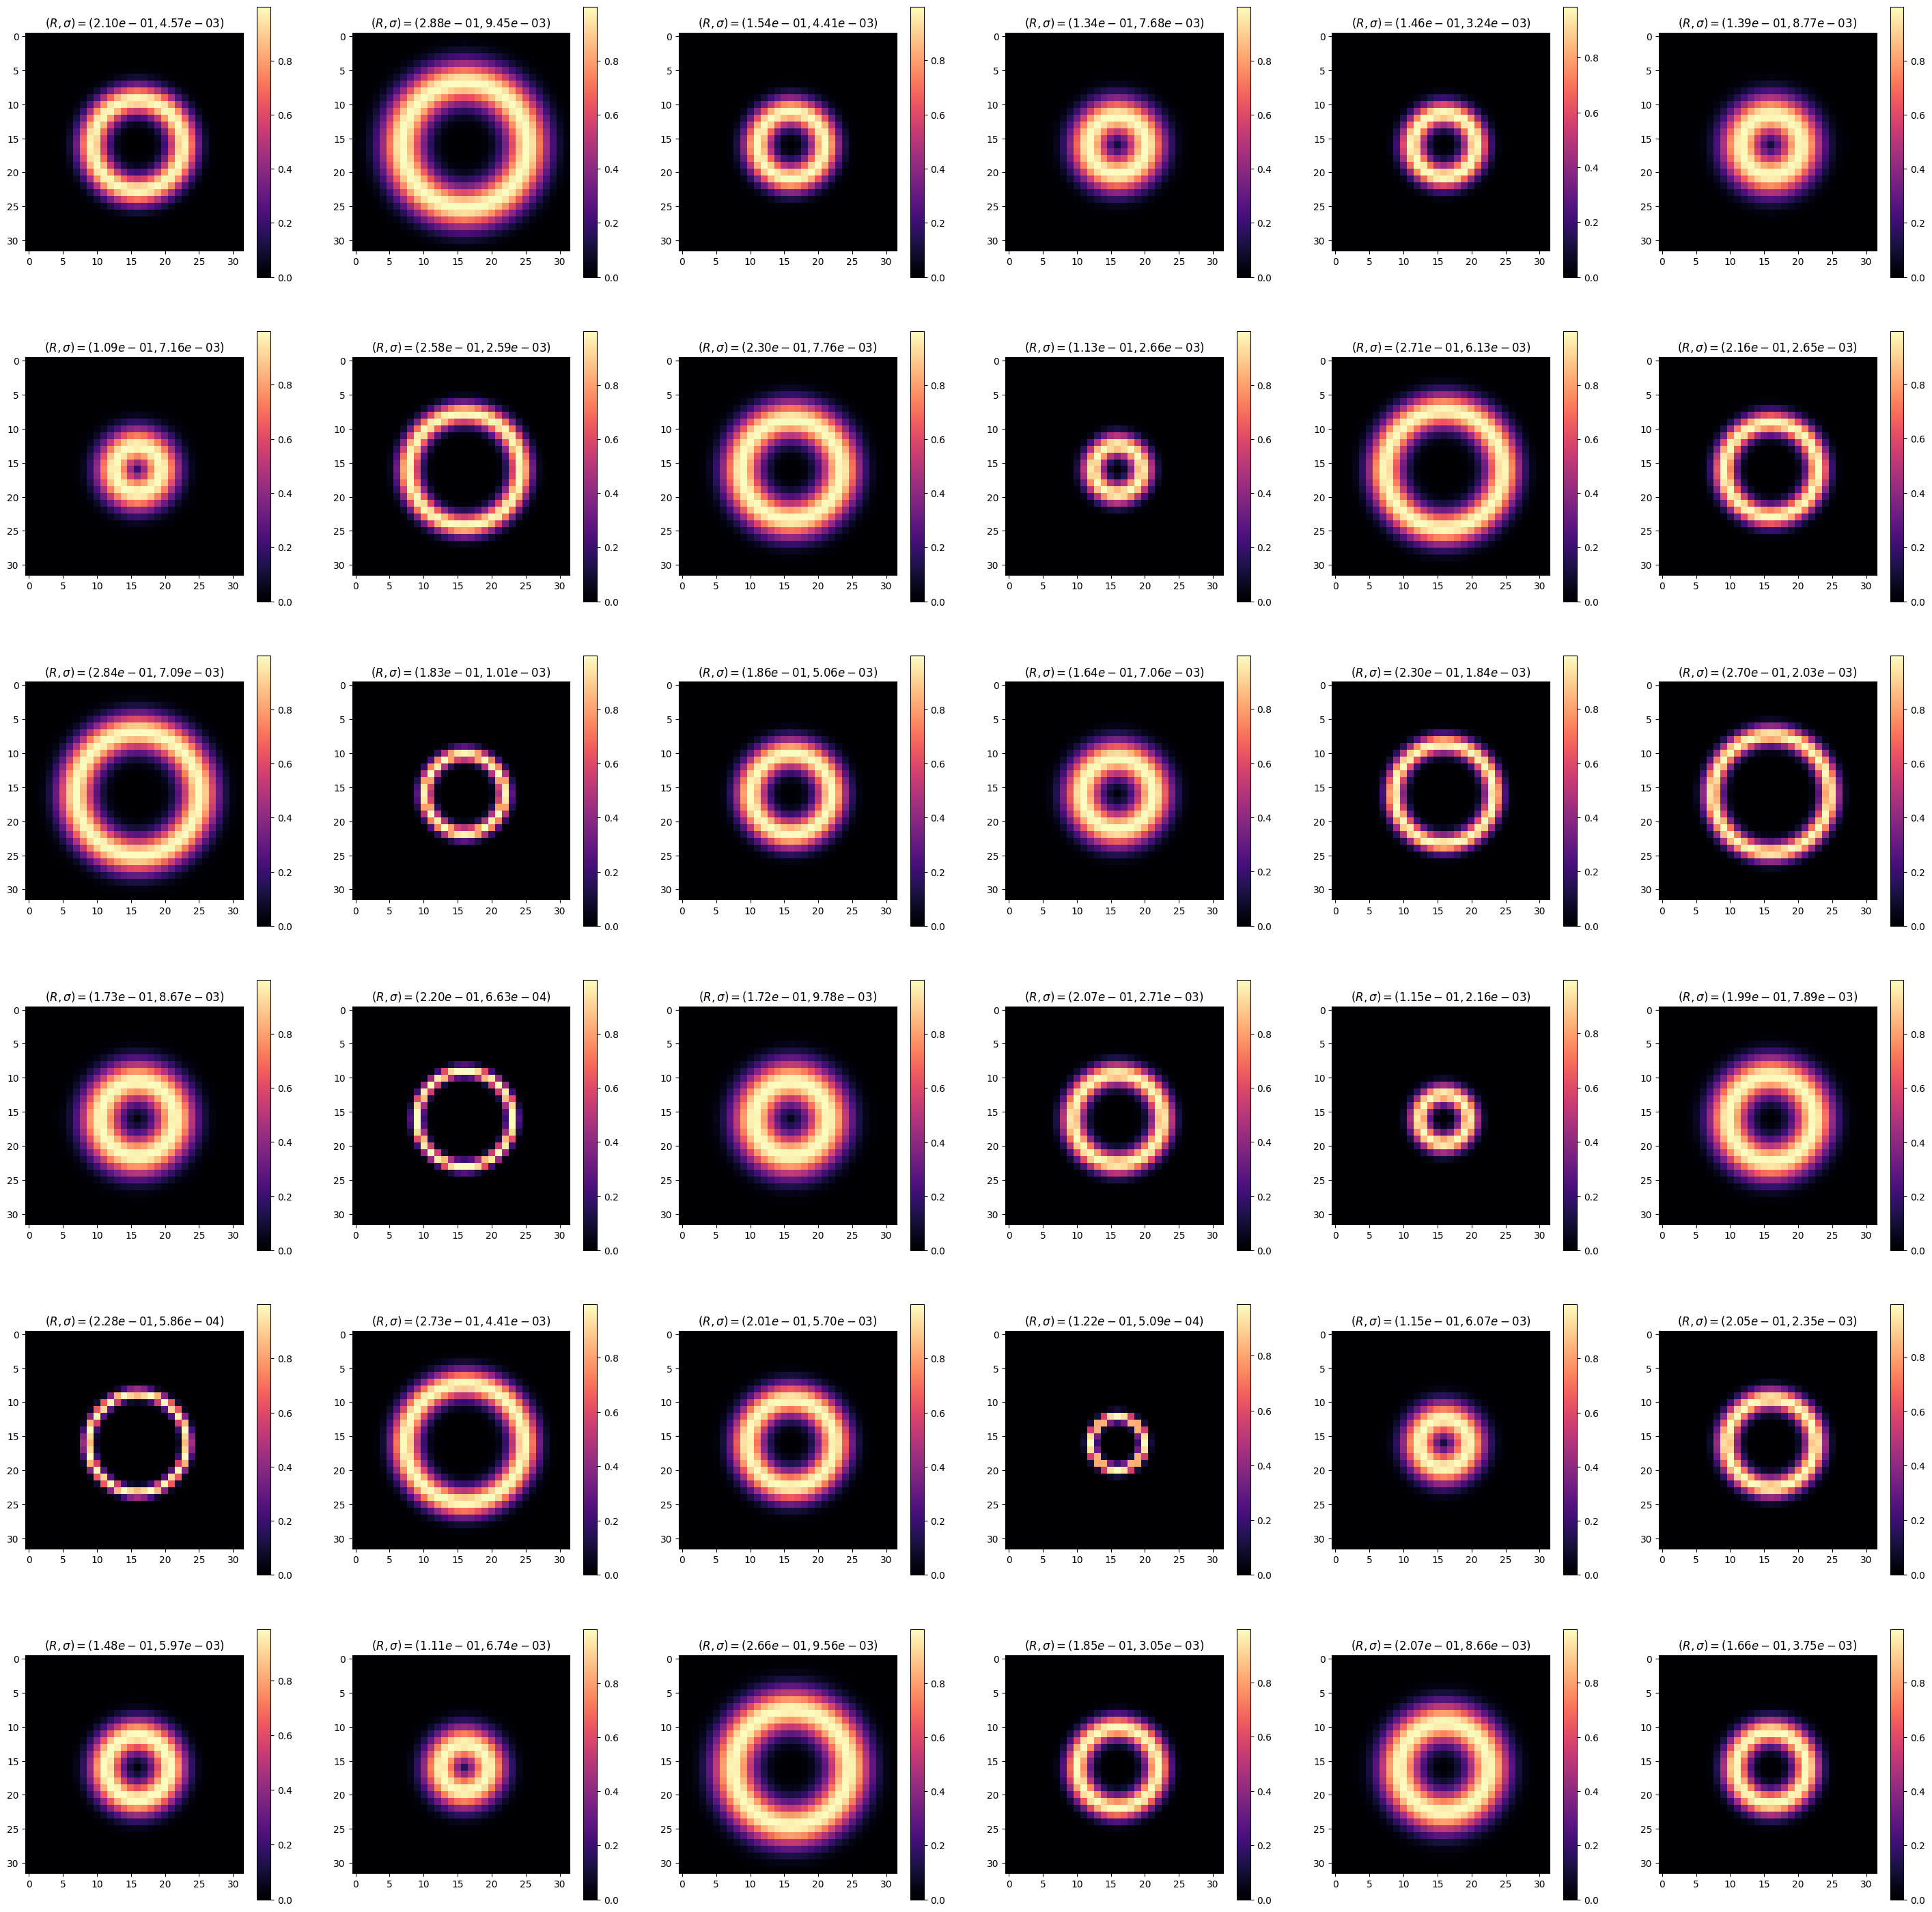

In [ ]:
fig, axs = plt.subplots(6, 6, figsize= (6 * 6, 6 * 6))

rings = images[:36]

for i, ax in enumerate(axs.flatten()): 
    im = ax.imshow(rings[i], cmap = "magma", vmin = 0)
    params = theta[i]
    ax.set_title(r"$(R, \sigma) = (%.2e,%.2e)$"%(params[0], params[1]))
    plt.colorbar(im, ax = ax)

In [ ]:
images.shape

(10000, 32, 32)

In [ ]:
theta

array([[ 2.51924828,  1.32726946],
       [11.25608679,  2.94860188],
       [25.30580591,  3.55337543],
       ...,
       [16.83613704,  4.68497306],
       [11.77987747,  2.38560095],
       [15.44827074,  4.26264754]], shape=(10000, 2))

In [6]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.facecolor'] = 'white'

prior_params_config = {
        "radius": {"low": 2, "high": 0.43}, 
        "sigma": {"low": 0.5, "high": 5}
    }

radius_prior = prior_params_config["radius"]
sigma_prior = prior_params_config["sigma"]
prior_sampler_radius = lambda size: np.random.uniform(radius_prior["low"], radius_prior["high"], size = size)
prior_sampler_sigma = lambda size: np.random.uniform(sigma_prior["low"], sigma_prior["high"], size = size)

dataset_size = 10000

# Creating latent factors
radius = (prior_sampler_radius(size = dataset_size) - radius_prior["low"]) / (radius_prior["high"] - radius_prior["low"])
sigma = (prior_sampler_sigma(size = dataset_size) - sigma_prior["low"]) / (sigma_prior["high"] - sigma_prior["low"])

(array([1002.,  957.,  968., 1014.,  976., 1028., 1012., 1001., 1004.,
        1038.]),
 array([8.25067039e-06, 9.99991528e-02, 1.99990055e-01, 2.99980957e-01,
        3.99971859e-01, 4.99962761e-01, 5.99953663e-01, 6.99944565e-01,
        7.99935467e-01, 8.99926369e-01, 9.99917272e-01]),
 <BarContainer object of 10 artists>)

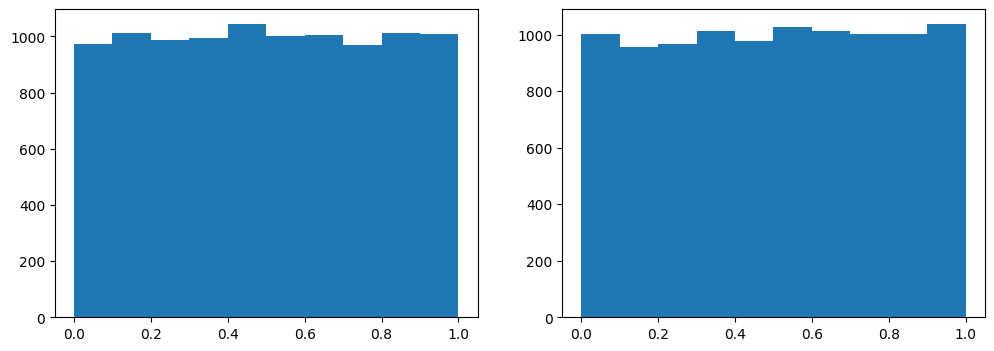

In [7]:
fig, axs = plt.subplots(1, 2, figsize = (12, 4))

ax = axs[0]
ax.hist(radius)

ax = axs[1]
ax.hist(sigma)

## Gravitational lenses 

In [1]:
import caustics
import torch 
import numpy as np
import matplotlib.pyplot as plt
from torch.nn.functional import avg_pool2d


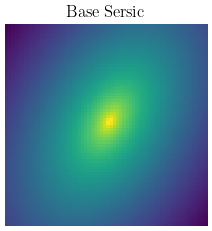

In [64]:
cosmology = caustics.FlatLambdaCDM()
cosmology.to(dtype=torch.float32)
z_s = torch.tensor(1.0)
z_l = torch.tensor(0.5, dtype=torch.float32)
base_sersic = caustics.Sersic(
    x0=0.1,
    y0=0.1,
    q=0.6,
    phi=np.pi / 3,
    n=2.0,
    Re=1.0,
    Ie=1.0,
)
n_pix = 32
res = 0.2
upsample_factor = 2
fov = res * n_pix
thx, thy = caustics.utils.meshgrid(
    res / upsample_factor,
    upsample_factor * n_pix,
    dtype=torch.float32,
)

plt.imshow(np.log10(base_sersic.brightness(thx, thy).numpy()), origin="lower")
plt.gca().axis("off")
plt.title("Base Sersic")
plt.show()

## Forward modeling the Sérsic source with a SIE lens.  

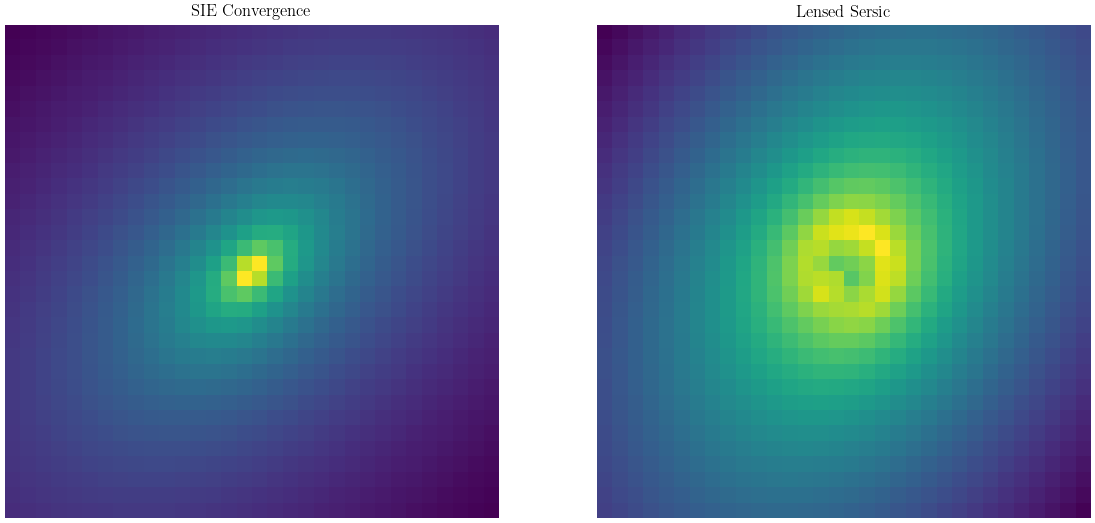

In [65]:
lens = caustics.SIE(
    cosmology=cosmology,
    x0=0.0,
    y0=0.0,
    q=0.6,
    phi=np.pi / 4,
    Rein=0.5,
    z_l=z_l,
    z_s=z_s,
)
sim = caustics.LensSource(
    lens=lens,
    source=base_sersic,
    pixelscale=res,
    pixels_x=n_pix,
    upsample_factor=2,
)

fig, axarr = plt.subplots(1, 2, figsize=(14, 7))
convergence = avg_pool2d(
    lens.convergence(thx, thy).squeeze()[None, None], upsample_factor
).squeeze()
axarr[0].imshow(np.log10(convergence.numpy()), origin="lower")
axarr[0].axis("off")
axarr[0].set_title("SIE Convergence")
axarr[1].imshow(np.log10(sim().numpy()), origin="lower")
axarr[1].axis("off")
axarr[1].set_title("Lensed Sersic")
plt.show()

We will only change the radius and the orientation of the lens $[R,\phi]$ for this experiment to be able to visualize the latent space. 

In [124]:
def simulate_system(Rein, phi):
    cosmology = caustics.FlatLambdaCDM()
    cosmology.to(dtype=torch.float32)
    z_s = torch.tensor(1.0)
    z_l = torch.tensor(0.5, dtype=torch.float32)
    base_sersic = caustics.Sersic(
        x0=0.1,
        y0=0.1,
        q=0.6,
        phi=np.pi / 3,
        n=2.0,
        Re=1.0,
        Ie=1.0,
    )
    n_pix = 32
    res = 0.2
    upsample_factor = 2

    lens = caustics.SIE(
                cosmology=cosmology,
                x0=0.0,
                y0=0.0,
                q=0.6,
                phi=phi,
                Rein=Rein,
                z_l=z_l,
                z_s=z_s,
        )
    sim = caustics.LensSource(
        lens=lens,
        source=base_sersic,
        pixelscale=res,
        pixels_x=n_pix,
        upsample_factor=2,
    )
    thx, thy = caustics.utils.meshgrid(
    res / upsample_factor,
    upsample_factor * n_pix,
    dtype=torch.float32
    )

    convergence = avg_pool2d(
        lens.convergence(thx, thy).squeeze()[None, None], upsample_factor
    ).squeeze()
    return sim().numpy(), convergence

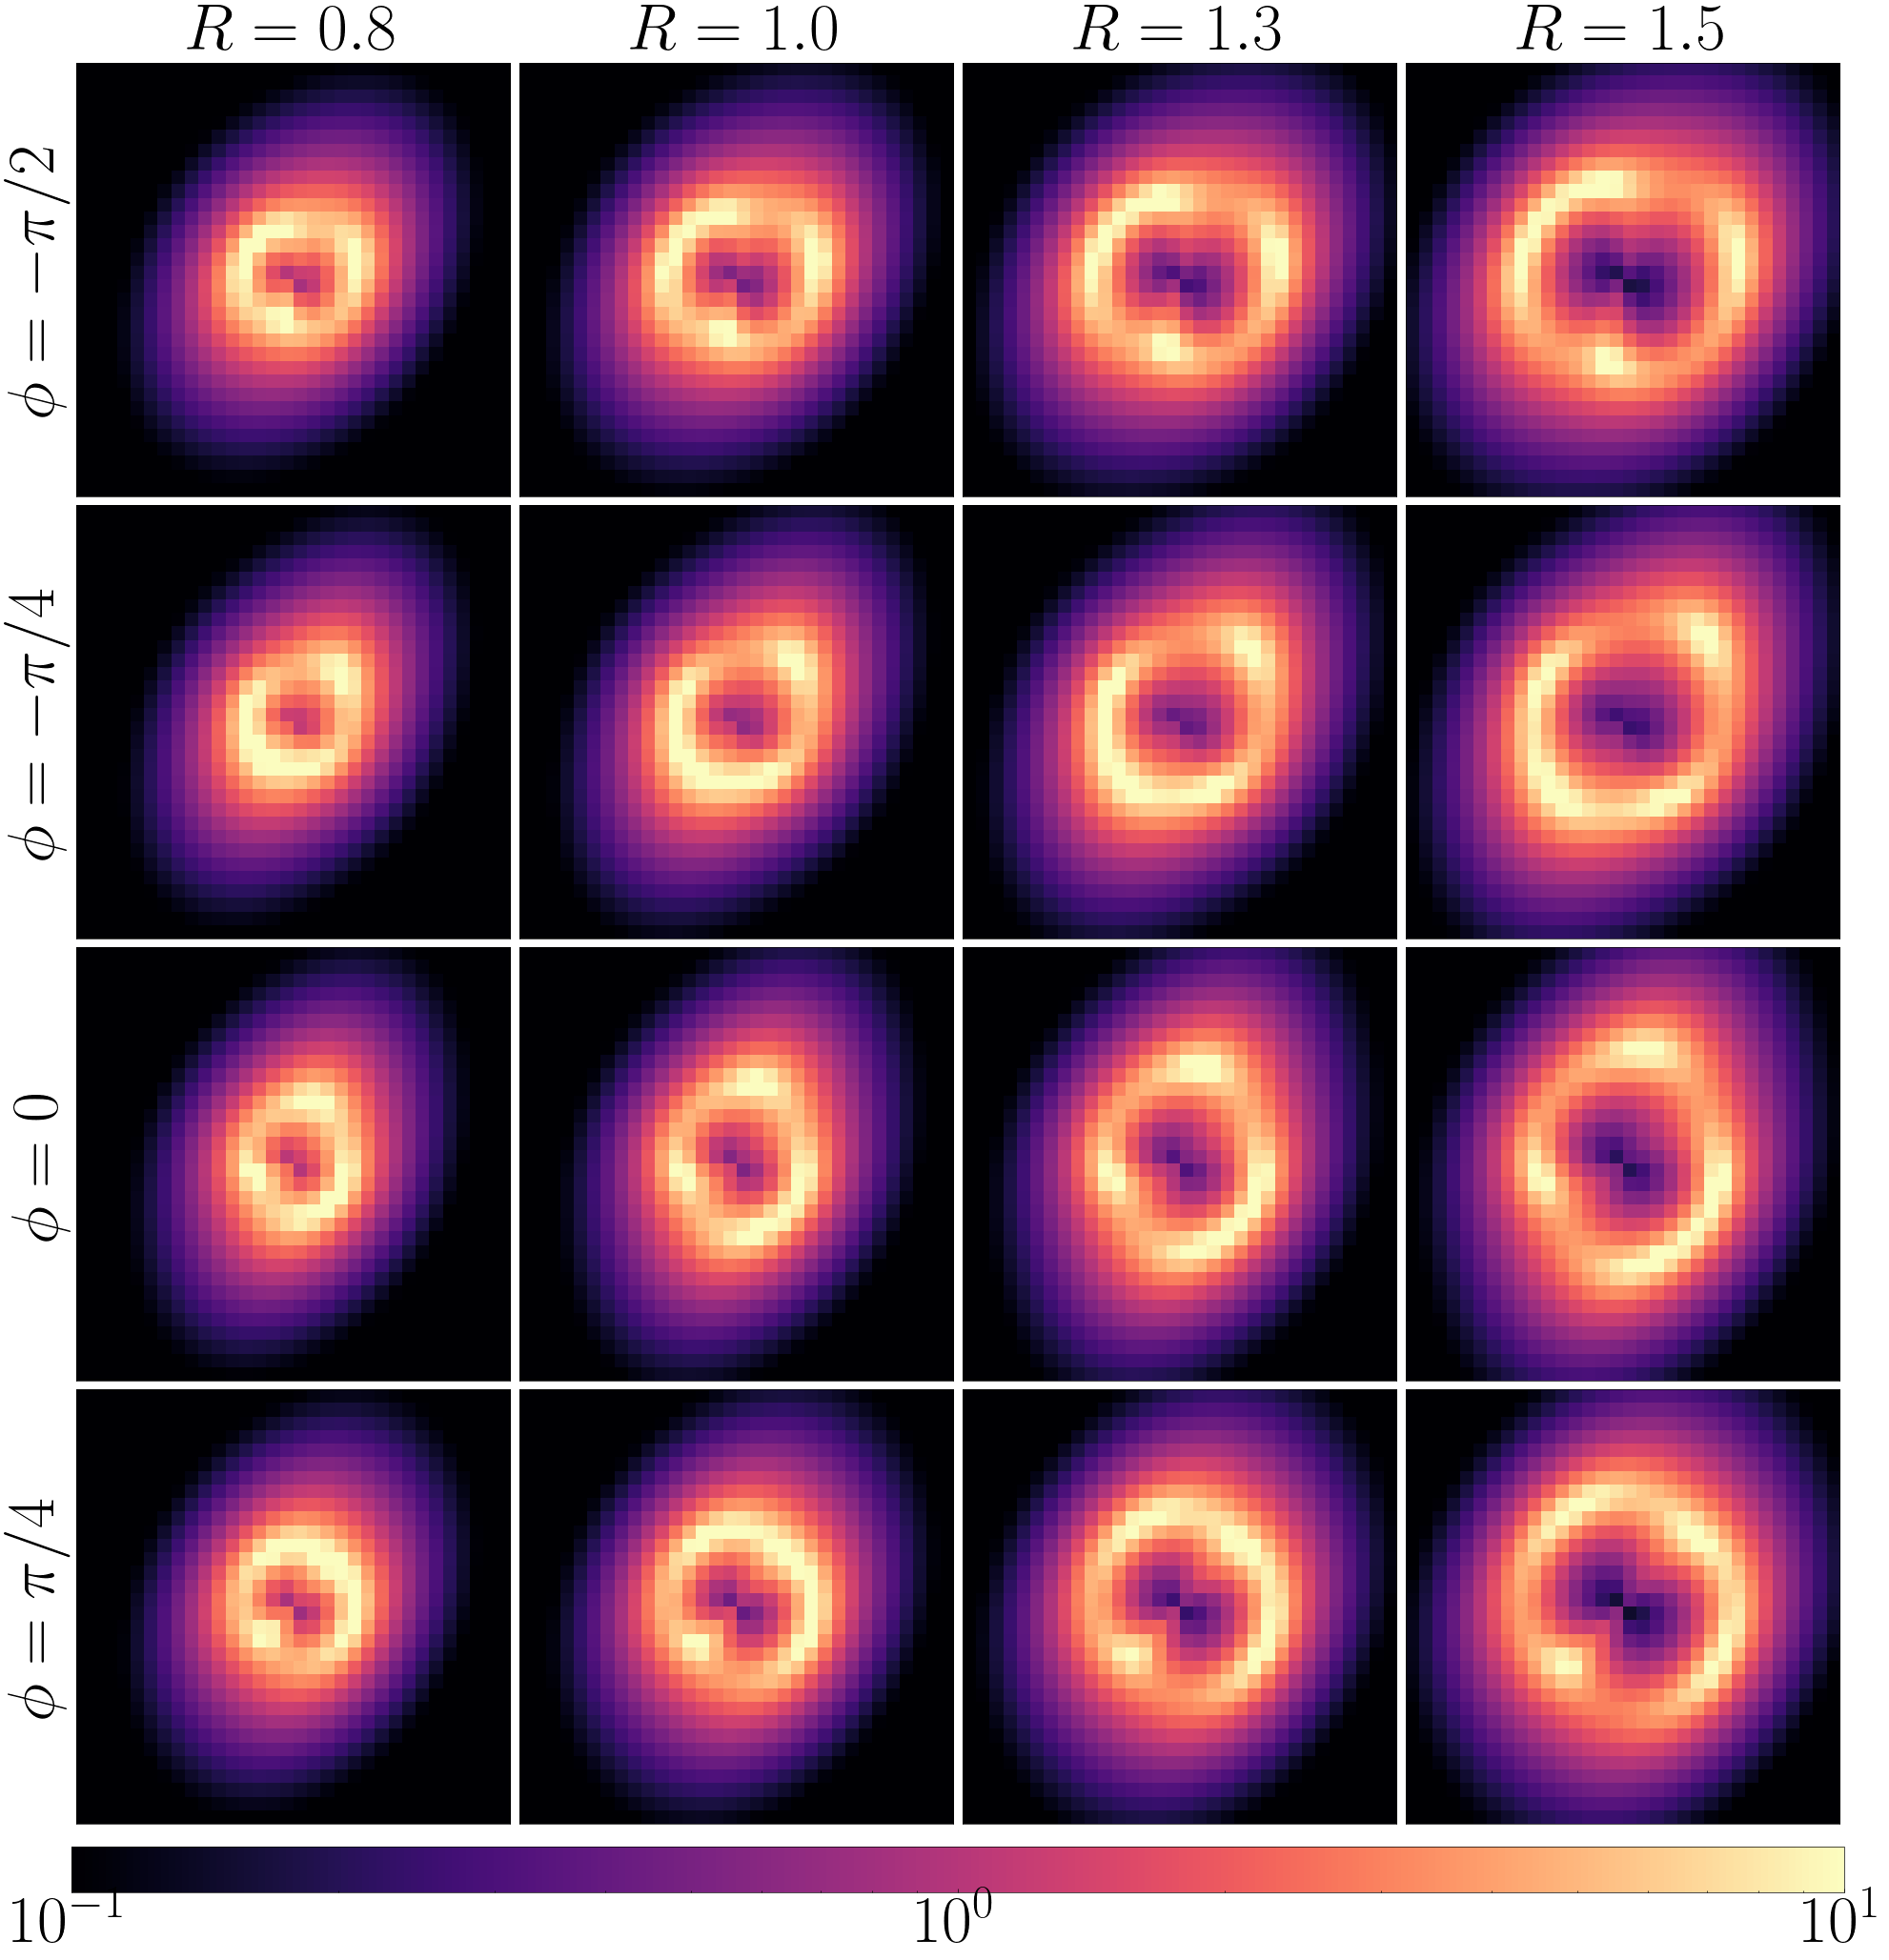

In [108]:
import scienceplots 
plt.style.use("science")
from matplotlib.colors import LogNorm
rad_min = 0.8
rad_max = 1.5

phi_min = -np.pi/2
phi_max = np.pi/4

num_plots = 4
rads = np.linspace(rad_min, rad_max, num_plots, endpoint=True)
phis = np.linspace(phi_min, phi_max, num_plots, endpoint=True)

fig, axs = plt.subplots(num_plots, num_plots, figsize = (6. * num_plots, 6 * num_plots))
cmap = "magma"
norm = LogNorm(vmin = 1e-1, vmax = 1e1)
fontsize = 50

for i in range(num_plots): 
    for j in range(num_plots):
        lens = caustics.SIE(
            cosmology=cosmology,
            x0=0.0,
            y0=0.0,
            q=0.6,
            phi=phis[i],
            Rein=rads[j],
            z_l=z_l,
            z_s=z_s,
        )
        sim = caustics.LensSource(
            lens=lens,
            source=base_sersic,
            pixelscale=res,
            pixels_x=n_pix,
            upsample_factor=2,
        )
        convergence = avg_pool2d(
            lens.convergence(thx, thy).squeeze()[None, None], upsample_factor
        ).squeeze()
        im = axs[i, j].imshow(sim().numpy(), origin="lower", cmap = cmap, norm = norm)
        # cbar = plt.colorbar(im, ax = axs[i, j], fraction = 0.0625, pad = 0, aspect = 15)
        # cbar.ax.tick_params(labelsize = 30)
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])

for j in range(num_plots): 
    axs[0, j].set_title(r"$R=%.1f$"%rads[j], fontsize = fontsize)

frac = [-2, -4, 0, 4]
for i in range(num_plots): 
    txt = r"$\phi=\pi/%d$"%frac[i] if frac[i]>0 else r"$\phi=-\pi/%d$"%abs(frac[i])
    if frac[i] == 0: 
        txt = r"$\phi=0$"
    axs[i, 0].set_ylabel(txt, fontsize = fontsize)

plt.subplots_adjust(wspace = 0., hspace = 0.02)
cbar_ax = fig.add_axes([0.125, 0.08, 0.775, 0.02]) 
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.ax.tick_params(labelsize=fontsize)
path = "C:/Users/noedi/Desktop/Ciela/Projects/classes/crl/data/figures"
plt.savefig(path + "/strong_lenses.pdf", bbox_inches = "tight")

Create function to sample lenses

In [113]:
prior_params_config = {
    "einstein_radius": {"low": 0.8, "high": 1.5}, 
    "phi": {"low": -np.pi/2, "high": np.pi/4}
}


radius_prior = prior_params_config["einstein_radius"]
phi_prior = prior_params_config["phi"]
prior_sampler_radius = lambda size: np.random.uniform(radius_prior["low"], radius_prior["high"], size = size)
prior_sampler_phi = lambda size: np.random.uniform(phi_prior["low"], phi_prior["high"], size = size)

[Text(0.5, 0, '$\\phi$'), Text(0, 0.5, 'Counts')]

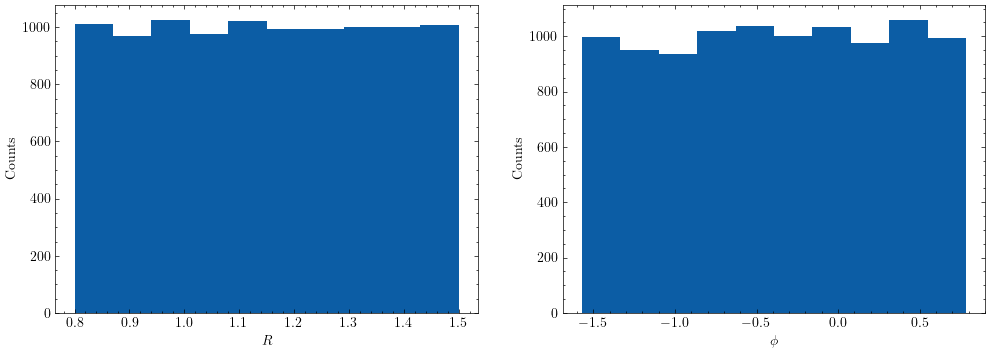

In [122]:
fig, axs = plt.subplots(1, 2, figsize = (6 * 2, 4))

dataset_size = 10_000
radii = prior_sampler_radius(dataset_size) 
phis = prior_sampler_phi(dataset_size)

theta = np.stack([radii, phis]).T
ax = axs[0]
ax.hist(theta[:, 0])
ax.set(xlabel = "$R$", ylabel = "Counts")
ax = axs[1]
ax.hist(theta[:, 1])
ax.set(xlabel = "$\phi$", ylabel = "Counts")

Simulating the strong lenses

In [125]:
from tqdm import tqdm
images = []
for param in tqdm(theta):
    sim, kappa = simulate_system(*param) 
    images.append(sim)

100%|██████████| 10000/10000 [00:54<00:00, 184.45it/s]


In [128]:
from datasets import Dataset
dset = Dataset.from_dict({
            "theta": theta,
            "image": np.array(images)
        })

dir = "C:/Users/noedi/Desktop/Ciela/Projects/classes/crl/data/datasets/strong_lenses"
dset.save_to_disk(dir)

Saving the dataset (1/1 shards): 100%|██████████| 10000/10000 [00:00<00:00, 271258.28 examples/s]


### LogNormal Density Field dataset

In [14]:
from astro_peek.utils import load_yaml
from astro_peek.datasets import *
from scipy.stats import uniform, loguniform
import matplotlib.pyplot as plt 
import scienceplots 
plt.style.use('science')
plt.rcParams.update({
         "font.size": 30,
         'xtick.major.size': 8, 
         'xtick.minor.size': 3,
         'xtick.major.width': 1.5,
         'xtick.minor.width': 1,
         'ytick.major.size': 8,
         'ytick.minor.size': 3,
         'ytick.major.width': 1.5,
         'ytick.minor.width': 1, 
         "lines.linewidth": 2,
        "legend.fontsize": 30,
         "image.cmap": "magma"
        })

prior_cfg = load_yaml("../../astro_peek/datasets/cosmo_prior.yaml")['priors']
priors = instantiate_priors(prior_cfg)


Making sure we have the right prior bounds

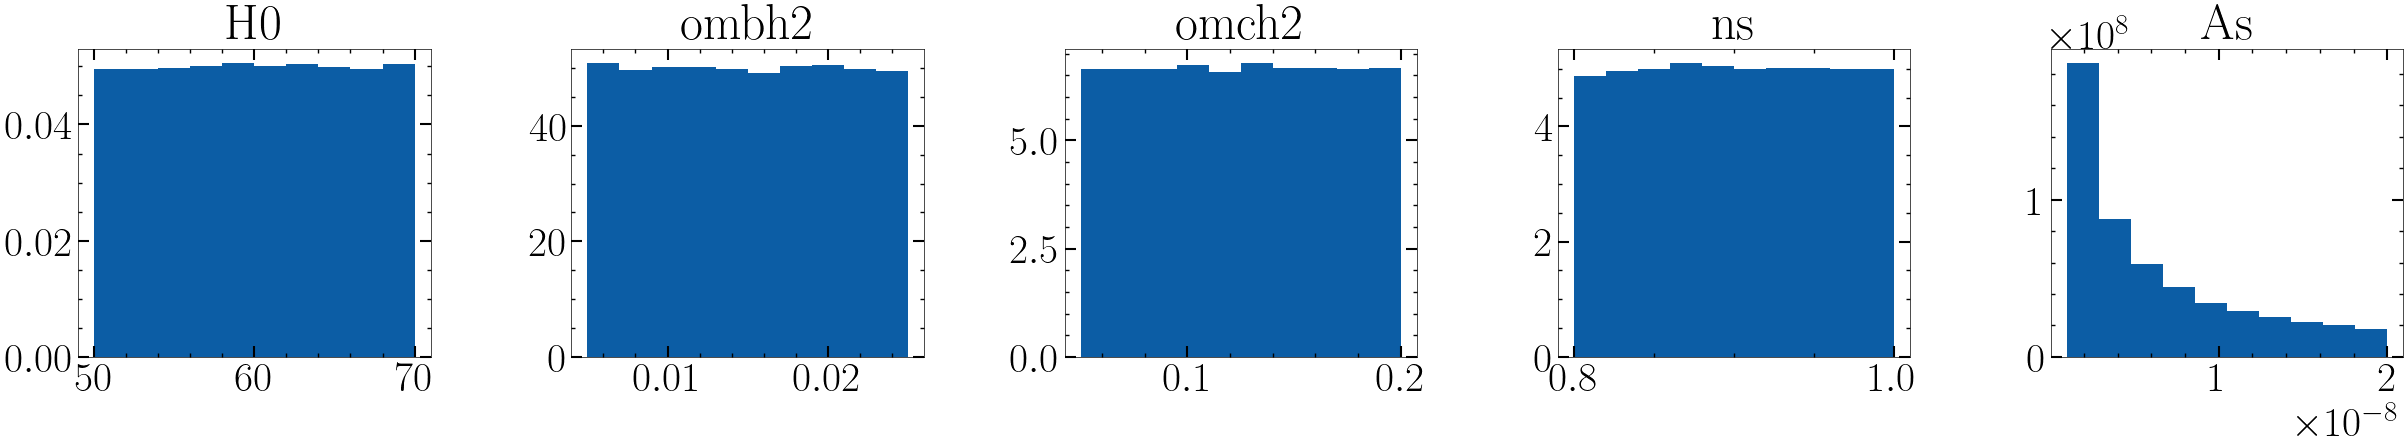

In [15]:
fig, axs = plt.subplots(1, 5, figsize = (6 * 5, 4))
psis = sample_priors(priors, num_samples = 100_000)
keys = list(priors.keys())
for i, ax in enumerate(axs): 
    ax.hist(psis[:, i], density = True)
    ax.set_title(keys[i])

plt.subplots_adjust(wspace = 0.4)

This looks good. Now, generating a Lognormal field volume and its a 2D slice.

In [16]:
from astro_peek.datasets import plot_volumes, compute_density_contrast_from_scratch, compute_pk
import numpy as np
camb_params = {
    "H0": 67.5,
    "ombh2": 0.022,
    "omch2": 0.05,
    "ns": 1.05,
    "As": 1e-10
}
kmin = 5e-3
kmax = 5e-1
pixel_size = 2 # Mpc/h
img_size = 128 # num cells per row/col
fov = img_size * pixel_size
seed = 0

k, Pk = compute_pk(camb_params, kmin = kmin, kmax = kmax)
delta_vol, delta = compute_density_contrast_from_scratch(camb_params, kmin = kmin, kmax = kmax, img_size = img_size, fov = fov, seed = seed, return_volume = True) 

(<Figure size 1200x400 with 1 Axes>, [<Axes3D: title={'center': 'Volume 0'}>])

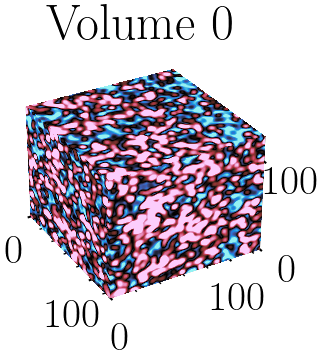

In [17]:
from cmap import Colormap
from astro_peek.datasets import plot_volumes
cmap = Colormap('cmasher:redshift').to_mpl()
plot_volumes([delta_vol], levels = np.linspace(-0.2, 0.2, 256), figsize= (12, 4), cmap = cmap)

#### Creating figures for the report

In [32]:
from astro_peek.datasets import plot_volumes, compute_density_contrast_from_scratch, compute_pk, compute_density_contrast_slice
import numpy as np
kmin = 1e-2
kmax = 5e-1
pixel_size = 2 # Mpc/h
img_size = 128 # num cells per row/col
fov = img_size * pixel_size
seed = 0

pks = []
deltas = []

omega_cs = [0.05, 0.1, 0.15, 0.2]
camb_params = {
    "H0": 67.5,
    "ombh2": 0.022,
    "omch2": 0.05,
    "ns": 1.05,
    "As": 1e-8
}


for omega_c in omega_cs: 
    camb_params["omch2"] = omega_c
    k, Pk = compute_pk(camb_params, kmin = kmin, kmax = kmax)
    pks.append(Pk)
    deltas.append(compute_density_contrast_slice(k, Pk, img_size = img_size, fov = fov, seed = seed, return_volume = False))

In [ ]:
print(2 * np.pi / fov, 2 * np.pi / pixel_size) # (kmin, kmax)

0.02454369260617026 3.141592653589793


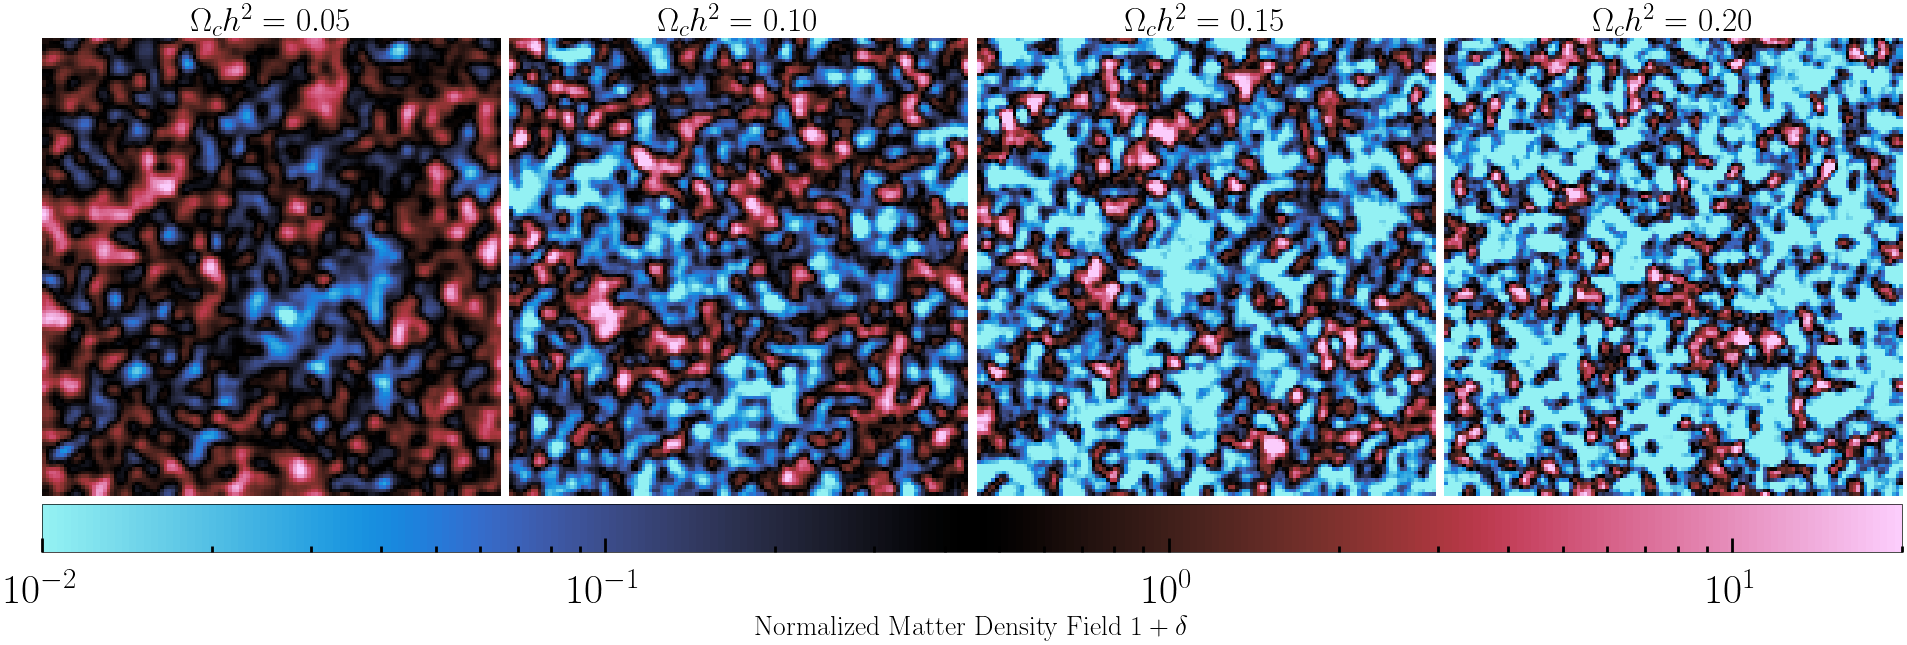

In [34]:
import powerbox as pbox
from scipy.interpolate import InterpolatedUnivariateSpline

fig, axs = plt.subplots(1, 4, figsize = (4 * 6, 6))
cmap = Colormap("cmasher:redshift").to_mpl()
for i, ax in enumerate(axs): 
    Omega_c = omega_cs[i]
    delta = deltas[i]
    norm = LogNorm(vmin = 1e-2, vmax = 2e1)
    im = ax.imshow(1 + delta, cmap = cmap, norm = norm)
    ax.set_title(r"$\Omega_c h^2 = %.2f$"%Omega_c)
    ax.axis("off")


plt.subplots_adjust(wspace = 0.02)
cbar_ax = fig.add_axes([0.125, 0.02, 0.775, 0.08]) 
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
fontsize = 30
cbar.ax.tick_params(labelsize=fontsize, which = "major", width = 2, length = 10, pad = 15)
cbar.ax.tick_params(labelsize=fontsize, which = "minor", width = 2, length = 4)
cbar.set_label(r"Normalized Matter Density Field $1+\delta$")
# plt.savefig("lrf_omegach2_varying.pdf", bbox_inches = "tight")

Plotting the power spectra. 

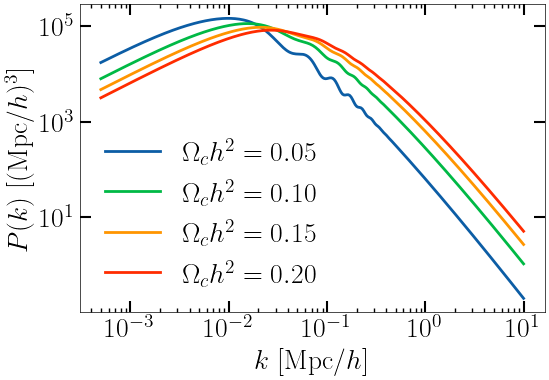

In [40]:
plt.rcParams.update({
         "font.size": 20,
         'xtick.major.size': 8, 
         'xtick.minor.size': 3,
         'xtick.major.width': 1.5,
         'xtick.minor.width': 1,
         'ytick.major.size': 8,
         'ytick.minor.size': 3,
         'ytick.major.width': 1.5,
         'ytick.minor.width': 1, 
         "lines.linewidth": 2,
        "legend.fontsize": 20,
         "image.cmap": "magma"
        })

fig, ax = plt.subplots(1, 1, figsize = (6, 4))
for i, omega_c in enumerate(omega_cs): 
    camb_params["omch2"] = omega_c
    k, Pk = compute_pk(camb_params, kmin = 5e-4, kmax = 1e1)
    im = ax.plot(k, Pk, label = r"$\Omega_c h^2 = %.2f$"%omega_c)
ax.loglog()
ax.minorticks_on()
ax.legend()
# ax.set_xticks([1e-3, 1e-2, 1e-1, 1e0])
ax.set(xlabel = r"$k$ [Mpc/$h$]", ylabel = r"$P(k)$ [(Mpc/$h$)$^3$]")
plt.savefig("matter_power_spectra.pdf", bbox_inches = "tight")

Plotting the priors over the cosmological parameters.

[Text(0, 0.5, 'Probability Density')]

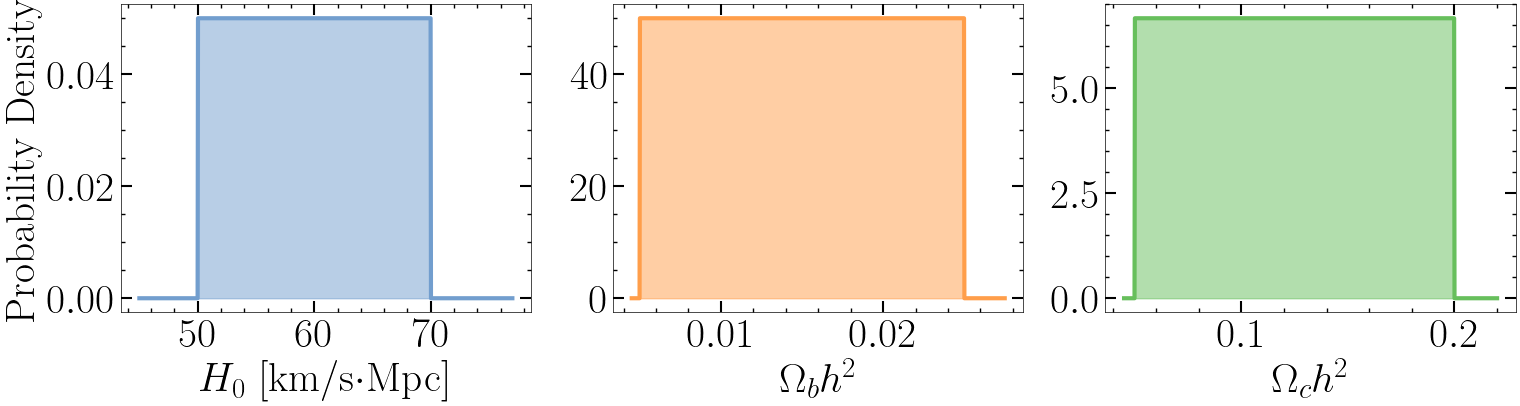

In [ ]:
from cmap import Colormap


cm = Colormap('seaborn:tab10_medium')  # case insensitive
fig, axs = plt.subplots(1, 3, figsize = (6 * 3, 4))


labels = [r"$H_0$ [km/s$\cdot$Mpc]", r"$\Omega_b h^2$", r"$\Omega_c h^2$", r"$n_s$", r"$A_s$"]
for i, ax in enumerate(axs):
    key = list(priors.keys())[i]
    prior = priors[key]
    support = prior.support()
    x = np.linspace(support[0]-support[0] / 10, support[1] + support[1]/10, 1000) 
    ax.fill_between(x, prior.pdf(x),  color = cm(i), alpha = 0.5)
    ax.plot(x, prior.pdf(x), color = cm(i), lw = 3)
    ax.set(xlabel = labels[i])
axs[0].set(ylabel = "Probability Density")

# plt.savefig("priors_cosmo_params_part1.pdf")

[Text(0, 0.5, 'Probability Density')]

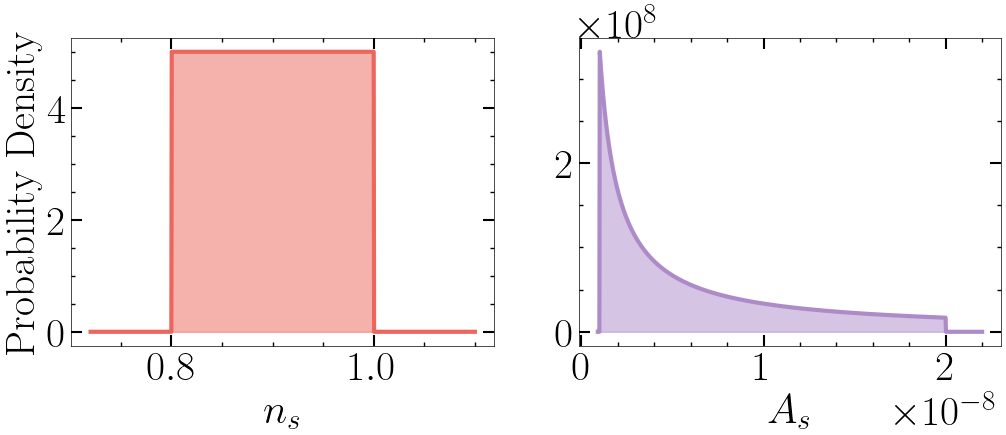

In [47]:
fig, axs = plt.subplots(1, 2, figsize = (6 * 2, 4))


labels = [r"$H_0$ [km/s$\cdot$Mpc]", r"$\Omega_b h^2$", r"$\Omega_c h^2$", r"$n_s$", r"$A_s$"]
for i, ax in enumerate(axs):
    key = list(priors.keys())[i+3]
    prior = priors[key]
    support = prior.support()
    x = np.linspace(support[0]-support[0] / 10, support[1] + support[1]/10, 1000) 
    ax.fill_between(x, prior.pdf(x),  color = cm(i+3), alpha = 0.5)
    ax.plot(x, prior.pdf(x), color = cm(i+3), lw = 3)
    ax.set(xlabel = labels[i+3])
axs[0].set(ylabel = "Probability Density")

# plt.savefig("priors_cosmo_params_part2.pdf")

Making the function to create the dataset

In [24]:
from astro_peek.utils import load_yaml
from astro_peek.datasets import plot_volumes, compute_density_contrast_from_scratch, compute_pk, compute_density_contrast_slice, instantiate_prior, sample_prior
import numpy as np
from scipy.stats import uniform, loguniform
import matplotlib.pyplot as plt 
import scienceplots 
plt.style.use('science')
plt.rcParams.update({
         "font.size": 30,
         'xtick.major.size': 8, 
         'xtick.minor.size': 3,
         'xtick.major.width': 1.5,
         'xtick.minor.width': 1,
         'ytick.major.size': 8,
         'ytick.minor.size': 3,
         'ytick.major.width': 1.5,
         'ytick.minor.width': 1, 
         "lines.linewidth": 2,
        "legend.fontsize": 30,
         "image.cmap": "magma"
        })
def str_to_float_cfg(cfg, keys = None):
    for key in keys:
        cfg[key] = float(cfg[key])
    return cfg

cfg = load_yaml("../../astro_peek/datasets/cosmo_prior.yaml")
prior_cfg = cfg['priors']
pk_cfg = str_to_float_cfg(cfg["matter_pk"], keys = ["kmin", "kmax"])
delta_cfg = str_to_float_cfg(cfg["density_field"], keys = ["kmin", "kmax"])
prior = instantiate_prior(prior_cfg)

print(pk_cfg)
print(delta_cfg)

{'kmin': 0.0005, 'kmax': 10.0}
{'kmin': 0.01, 'kmax': 0.5, 'img_size': 128, 'fov': 256}


In [28]:
from tqdm import tqdm
num_cosmo = 5
psis = sample_prior(prior, num_cosmo)
seed = 0
num_fields_per_cosmo = 10
img_size = int(delta_cfg['img_size'])
deltas = np.empty(shape = (num_cosmo, num_fields_per_cosmo, img_size, img_size))   # (N_cosmo, N_field_per_cosmo, img_size, img_size)
pks =   np.empty(shape = (num_cosmo, 300)) # (N_cosmo, 300)

# Looping over cosmologies to create power spectrum and density contrast fields.
for i in tqdm(range(num_cosmo)): 
    psi = psis[i]
    prior_sample = {key: psi[i] for i, key in enumerate(priors.keys())}
    k, Pk = compute_pk(prior_sample, **pk_cfg)
    pks[i] = Pk

    for j in range(num_fields_per_cosmo):
        delta = compute_density_contrast_from_scratch(prior_sample, seed = seed, return_volume = False, **delta_cfg)
        seed += 1
        deltas[i, j] = delta
from datasets import Dataset, DatasetInfo

info = DatasetInfo(description = "Dataset of matter power spectra and Lognormal density contrasts for varying (H0, Omega_b, Omega_c, n_s, A_s)")
dset = Dataset.from_dict({
    "power_spectrum": pks,
    "density_contrast": deltas ,
    "cosmo_params": psis 
}, info = info)

100%|██████████| 5/5 [03:05<00:00, 37.18s/it]


Dataset({
    features: ['power_spectrum', 'density_contrast', 'cosmo_params'],
    num_rows: 5
})